In [1]:
!pip install jiwer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 81.2 MB/s eta 0:00:00:00:01


In [2]:
import os
import numpy as np
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import Dataset, DataLoader
import torchaudio
import torchaudio.transforms as T
import torchaudio.functional as F
import matplotlib.pyplot as plt
from transformers import Wav2Vec2CTCTokenizer, get_cosine_schedule_with_warmup
from jiwer import wer
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("USING DEVICE: ",device)

import kagglehub

seed=42
np.random.seed(seed)
torch.manual_seed(seed)



USING DEVICE:  cuda


In [4]:
tokenizer=Wav2Vec2CTCTokenizer.from_pretrained("facebook/wav2vec2-base")

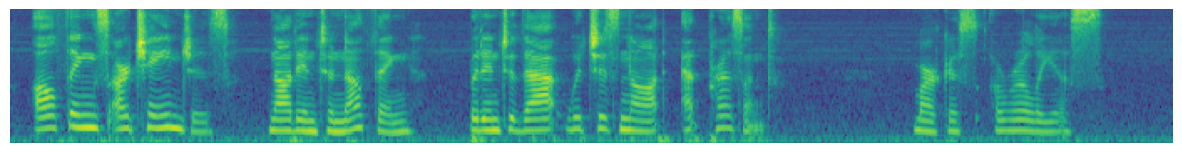

In [5]:
class LibriSpeechDataset(Dataset):
    def __init__(self,path_to_data_root,include_splits=["train-clean-100","train-clean-360","train-other-500"],
                 sampling_rate=16000,
                 num_audio_channels=1):

        if isinstance(include_splits,str):
            include_splits=[include_splits]

        self.sampling_rate=sampling_rate
        self.num_audio_channels=num_audio_channels
        self.librispeech_data=[]

        for split in include_splits:
            path_to_split_1=os.path.join(path_to_data_root,split)
            path_to_split_2=os.path.join(path_to_split_1,"LibriSpeech")
            path_to_split=os.path.join(path_to_split_2,split)

            for speaker in os.listdir(path_to_split):
                path_to_speaker=os.path.join(path_to_split,speaker)
                for section in os.listdir(path_to_speaker):
                    path_to_section = os.path.join(path_to_speaker, section)
                    files=os.listdir(path_to_section)
                    transcript_file=[path for path in files if ".txt" in path][0]
                    with open(os.path.join(path_to_section, transcript_file), "r") as f:
                        transcripts = f.readlines()

                    for line in transcripts:
                        split_line = line.split()
                        audio_root = split_line[0]
                        audio_file = audio_root + ".flac"
                        full_path_to_audio_file = os.path.join(path_to_section, audio_file)
                        transcript = " ".join(split_line[1:]).strip()

                        self.librispeech_data.append(
                            (full_path_to_audio_file,transcript)
                        )

        self.audio2mels =  T.MelSpectrogram(
            sample_rate=sampling_rate,
            n_mels=80
        )

        self.amp2db = T.AmplitudeToDB(
            top_db=80.0
        )
    def __len__(self):
        return len(self.librispeech_data)

    def __getitem__(self, idx):
        
        path_to_audio, transcript = self.librispeech_data[idx]
        audio, orig_sr = torchaudio.load(path_to_audio, normalize=True)

        if orig_sr != self.sampling_rate:
            audio = torchaudio.functional.resample(audio, orig_freq=orig_sr, new_freq=self.sampling_rate)
        
        mel = self.audio2mels(audio)
        mel = self.amp2db(mel)
        mel = (mel - mel.mean()) / (mel.std() + 1e-6)

        tokenized_transcript = torch.tensor(tokenizer.encode(transcript))

        sample = {"input_values": mel[0].T, 
                  "labels": tokenized_transcript}
        
        return sample
dataset = LibriSpeechDataset(path_to_data_root="/kaggle/input/datasets/a24998667/librispeech", 
                             include_splits="train-clean-100")

sample=next(iter(dataset))
plt.figure(figsize=(15,5))
plt.imshow(sample["input_values"].T)
plt.axis("off")
plt.gca().invert_yaxis()
plt.show()

Input Values: torch.Size([5, 1, 80, 1297])
Seq Lens tensor([1297, 1242, 1221,  899,  695])
Labels: torch.Size([830])
Target Lengths: tensor([235, 167, 187, 148,  93])
Sucess, Same Length


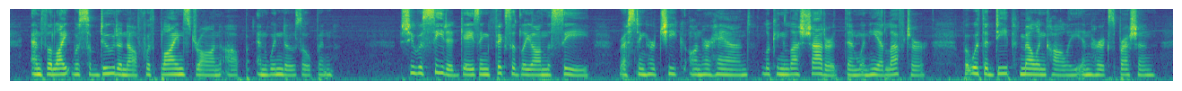

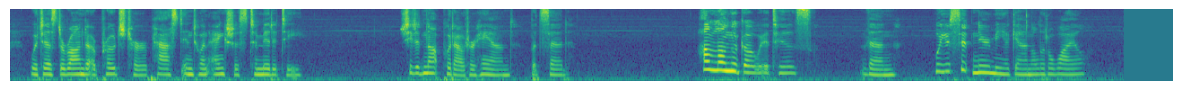

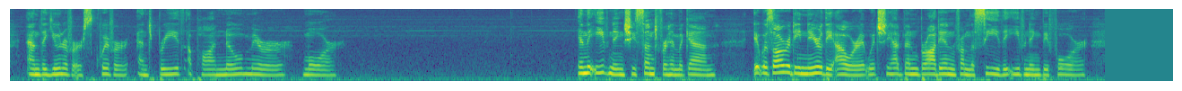

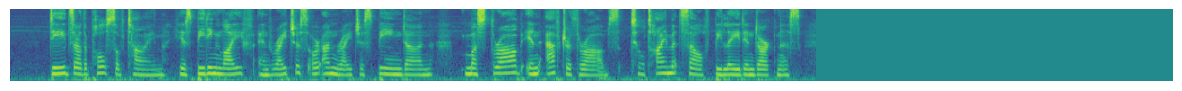

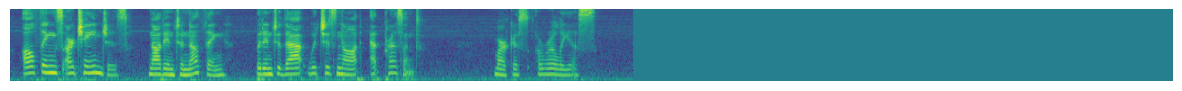

In [6]:
#collate_function
def collate_fn(batch):
    batch=sorted(batch,key=lambda x:x["input_values"].shape[0],reverse=True )
    batch_mels=[sample["input_values"] for sample in batch]
    batch_transcripts=[sample["labels"] for sample in batch]
    seq_lens=torch.tensor([b.shape[0] for b in batch_mels],dtype=torch.long)
    spectrograms = torch.nn.utils.rnn.pad_sequence(batch_mels, batch_first=True, padding_value=0)
    spectrograms = spectrograms.unsqueeze(1).transpose(-1,-2)
    target_lengths=torch.tensor([len(t) for t in batch_transcripts],dtype=torch.long)
    packed_transcripts=torch.cat(batch_transcripts)
    batch={
        "input_values":spectrograms,
        "seq_lens":seq_lens,
        "labels":packed_transcripts,
        "target_lengths":target_lengths
    }

    return batch
loader = DataLoader(dataset, batch_size=5, collate_fn=collate_fn)
batch = next(iter(loader))

print("Input Values:", batch["input_values"].shape)
print("Seq Lens", batch["seq_lens"])
print("Labels:", batch["labels"].shape)
print("Target Lengths:", batch["target_lengths"])
if batch["target_lengths"].sum() == len(batch["labels"]):
    print("Sucess, Same Length")

for samp in batch["input_values"]:
    
    plt.figure(figsize=(15,5))
    plt.imshow(samp.squeeze())
    plt.axis("off")
    plt.gca().invert_yaxis()
    plt.show()

In [7]:
#We have to downsample the spectrogram to avoide trainning on padded area 
#for that we will use conv layer 

conv = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=(3,3), stride=(1,2), padding=(1,0))

output = conv(batch["input_values"])

print("Output Shape:", output.shape)

Output Shape: torch.Size([5, 1, 80, 648])


In [8]:
#outputs says 648 i.e nearly half of maximum value of our previous batch 1297/2
#for clarification
padding = 0
kernel_size = 3
stride = 2

print("Input Seq Lens:", batch["seq_lens"])

output_seq_lens = torch.floor((batch["seq_lens"] + (2 * padding) - (kernel_size - 1) - 1) // stride + 1)

print("Output Seq Lens:", output_seq_lens)

Input Seq Lens: tensor([1297, 1242, 1221,  899,  695])
Output Seq Lens: tensor([648, 620, 610, 449, 347])


In [10]:
#now we have output sequence length of every spectrogram so all sequence length after it is useless so we will create a mask upto this sequence length
mask = torch.nn.utils.rnn.pad_sequence([torch.ones(i) for i in output_seq_lens], padding_value=0, batch_first=True)

print("Shortest Sample Without Mask")
print(output[-1], "\n")

output = output * mask.unsqueeze(1).unsqueeze(1)

print("Shortest Sample With Mask")
print(output[-1], "\n")


Shortest Sample Without Mask
tensor([[[ 0.2376,  0.5192, -0.1322,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.3289,  0.1347,  0.0169,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.3744,  0.0490,  0.0912,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [-0.5282, -0.2958, -0.6521,  ...,  0.0000,  0.0000,  0.0000],
         [-0.4705, -0.5186, -0.6522,  ...,  0.0000,  0.0000,  0.0000],
         [-0.1264, -0.3100, -0.1840,  ...,  0.0000,  0.0000,  0.0000]]],
       grad_fn=<SelectBackward0>) 

Shortest Sample With Mask
tensor([[[ 0.2376,  0.5192, -0.1322,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.3289,  0.1347,  0.0169,  ...,  0.0000,  0.0000,  0.0000],
         [ 0.3744,  0.0490,  0.0912,  ...,  0.0000,  0.0000,  0.0000],
         ...,
         [-0.5282, -0.2958, -0.6521,  ...,  0.0000,  0.0000,  0.0000],
         [-0.4705, -0.5186, -0.6522,  ...,  0.0000,  0.0000,  0.0000],
         [-0.1264, -0.3100, -0.1840,  ...,  0.0000,  0.0000,  0.0000]]],
       grad_fn=<SelectBac

In [11]:

#all in one masking 
class MaskedConv2d(nn.Conv2d):
    def __init__(self, 
                 in_channels,
                 out_channels, 
                 kernel_size,
                 stride, 
                 padding=0,
                 bias=True,
                 **kwargs):
        
        super(MaskedConv2d, self).__init__(in_channels=in_channels, 
                                           out_channels=out_channels, 
                                           kernel_size=kernel_size, 
                                           stride=stride, 
                                           padding=padding, 
                                           bias=bias, 
                                           **kwargs)

    def forward(self, x, seq_lens):


        batch_size, channels, height, width = x.shape
        
        output_seq_lens = self._compute_output_seq_len(seq_lens)

        conv_out = super().forward(x)

        mask = torch.zeros(batch_size, output_seq_lens.max(), device=x.device)
        for i, length in enumerate(output_seq_lens):
            mask[i, :length] = 1

        mask = mask.unsqueeze(1).unsqueeze(1)

        conv_out = conv_out * mask

        return conv_out, output_seq_lens


    def _compute_output_seq_len(self,seq_lens):
        return torch.floor((seq_lens + (2 * self.padding[1]) - (self.kernel_size[1] - 1) - 1) // self.stride[1]) + 1

In [12]:

#Adding a layer using our masked conv layer for feature extraction
class ConvolutionFeatureExtractor(nn.Module):

    def __init__(self, 
                 in_channels=1, 
                 out_channels=32):

        super(ConvolutionFeatureExtractor, self).__init__()

        self.in_channels = in_channels, 
        self.out_channels = out_channels

        self.conv1 = MaskedConv2d(in_channels, out_channels, kernel_size=(11, 41), stride=(2,2), padding=(5,20), bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        
        self.conv2 = MaskedConv2d(out_channels, out_channels, kernel_size=(11, 21), stride=(2,1), padding=(5,10), bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.output_feature_dim = 20
        self.conv_output_features = self.output_feature_dim * self.out_channels
    def forward(self,x,seq_lens):
        print(x.shape)
        print(seq_lens)
        x, seq_lens = self.conv1(x, seq_lens)
        x = self.bn1(x)
        x = torch.nn.functional.hardtanh(x)
        
        x, seq_lens = self.conv2(x, seq_lens)
        x = self.bn2(x)
        x = torch.nn.functional.hardtanh(x)
        
        x = x.permute(0,3,1,2).flatten(2)

        return x,seq_lens


In [13]:
#now we will us rnn for processing sequence information (bidirectional rnn)
conv=ConvolutionFeatureExtractor()
conv_out,out_seq_lens=conv(batch["input_values"],batch["seq_lens"])
print("Convolution Output:",conv_out.shape)
print("valid seq_lens:",out_seq_lens)
packed_conv_out=nn.utils.rnn.pack_padded_sequence(conv_out,out_seq_lens,batch_first=True)
print("Packed Output")
print(packed_conv_out)


torch.Size([5, 1, 80, 1297])
tensor([1297, 1242, 1221,  899,  695])
Convolution Output: torch.Size([5, 649, 640])
valid seq_lens: tensor([649, 621, 611, 450, 348])
Packed Output
PackedSequence(data=tensor([[ 0.5864,  1.0000,  0.6689,  ...,  1.0000,  1.0000,  1.0000],
        [ 0.5391,  1.0000,  0.6653,  ...,  1.0000,  1.0000,  1.0000],
        [ 1.0000,  1.0000,  1.0000,  ...,  0.6757,  0.4602,  0.6402],
        ...,
        [ 0.1952, -0.3754, -0.2701,  ..., -0.5990, -1.0000, -0.8354],
        [-0.2787,  0.1389, -0.3576,  ..., -0.3855, -0.6856, -0.1437],
        [ 0.6956, -0.2766, -0.6350,  ..., -0.0619, -0.5351,  0.3601]],
       grad_fn=<PackPaddedSequenceBackward0>), batch_sizes=tensor([5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5

In [14]:
class RNNLayer(nn.Module):
    def __init__(self,input_size,hidden_size=512):
        super(RNNLayer,self).__init__()
        self.hidden_dim=hidden_size
        self.input_size=input_size
        self.rnn=nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True,
            bidirectional=True,
        )
        self.layernorm=nn.LayerNorm(2*hidden_size)

    def forward(self,x,seq_lens):
        batch,seq_len,embed_dim=x.shape
        packed_x=nn.utils.rnn.pack_padded_sequence(x,seq_lens,batch_first=True)
        out,_=self.rnn(packed_x)
        x,_=nn.utils.rnn.pad_packed_sequence(out,total_length=seq_len,batch_first=True)
        x=self.layernorm(x)
        return x

In [25]:
#final nn we are designing is DeepSpeech2

class DeepSpeech2(nn.Module):
    def __init__(self,conv_in_channels=1,
                conv_out_channels=32,
                rnn_hidden_size=512,
                rnn_depth=5):
        super(DeepSpeech2,self).__init__()
        self.feature_extractor=ConvolutionFeatureExtractor(
            conv_in_channels,conv_out_channels
        )
        self.output_hidden_features=self.feature_extractor.conv_output_features
        self.rnns = nn.ModuleList(
            [
                RNNLayer(input_size=self.output_hidden_features if i==0 else 2 * rnn_hidden_size,
                         hidden_size=rnn_hidden_size)
                for i in range(rnn_depth)
            ]
        )
        self.head = nn.Sequential(
            nn.Linear(2 * rnn_hidden_size, rnn_hidden_size), 
            nn.Hardtanh(), 
            nn.Linear(rnn_hidden_size, tokenizer.vocab_size)
        )

    def forward(self,x,seq_lens):
        x,first_seq_lens=self.feature_extractor(x,seq_lens)
        for rnn in self.rnns:
            x=rnn(x,first_seq_lens)

        x=self.head(x)
        return x ,first_seq_lens

In [32]:
BATCH_SIZE = 32
TRAINING_ITERATIONS = 50000
EVAL_ITERATIONS = 2500
LEARNING_RATE = 1e-4
NUM_WORKERS = 32
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DATASET_ROOT = "/kaggle/input/datasets/a24998667/librispeech"
trainset = LibriSpeechDataset(path_to_data_root=DATASET_ROOT, include_splits=["train-clean-100", "train-clean-360", "train-other-500"])
testset =  LibriSpeechDataset(path_to_data_root=DATASET_ROOT, include_splits=["test-clean", "dev-clean"])
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=NUM_WORKERS)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=NUM_WORKERS)
model = DeepSpeech2(conv_in_channels=1, 
                    conv_out_channels=32, 
                    rnn_hidden_size=512).to(DEVICE)

params = sum([p.numel() for p in model.parameters()])
print("Total Training Parameters:", params)
optimizer = optim.AdamW(params=model.parameters(), lr=LEARNING_RATE)
scheduler = get_cosine_schedule_with_warmup(optimizer, 
                                            num_warmup_steps=500, 
                                            num_training_steps=TRAINING_ITERATIONS)

Total Training Parameters: 30727936


In [27]:
from huggingface_hub import HfApi
import torch.optim as optim
import glob
EPOCHS    = 100
SAVE_DIR  = '/kaggle/working/checkpoints'
os.makedirs(SAVE_DIR, exist_ok=True)

HF_TOKEN   = 'YOUR_HF_TOKEN'          # paste your HF write token
HF_REPO_ID = 'chitransh001/STT_SpeechToText'  # e.g. chitransh001/googlenet-imagenet100
hf_api     = HfApi()

existing    = sorted(glob.glob(f'{SAVE_DIR}/checkpoint_epoch_*.pth'))
AUTO_RESUME = existing[-1] if existing else None
if AUTO_RESUME:
    print(f'Will resume from: {AUTO_RESUME}')
else:
    print('No checkpoint found — starting fresh')


No checkpoint found — starting fresh


In [28]:
def upload_to_hf(local_path):
    """Upload a file to HuggingFace Hub. Silently skips if token not set."""
    if HF_TOKEN == 'YOUR_HF_TOKEN':
        return  # not configured yet
    try:
        hf_api.upload_file(
            path_or_fileobj = local_path,
            path_in_repo    = os.path.basename(local_path),
            repo_id         = HF_REPO_ID,
            repo_type       = 'model',
            token           = HF_TOKEN,
        )
        print(f'  [HF] Uploaded {os.path.basename(local_path)} -> {HF_REPO_ID}')
    except Exception as e:
        print(f'  [HF] Upload failed (non-fatal): {e}')

def save_checkpoint(epoch, model, optimizer, scheduler, best_acc, val_acc_history, path):
    state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
    torch.save({
        'epoch':            epoch,
        'model_state_dict': state,
        'optim_state_dict': optimizer.state_dict(),
        'sched_state_dict': scheduler.state_dict(),
        'best_acc':         best_acc,
        'val_acc_history':  val_acc_history,
    }, path)
    print(f'  [Checkpoint] Saved -> {path}')
    sys.stdout.flush()  # force output so Kaggle doesn't think kernel is idle
    upload_to_hf(path)  # push to HF immediately after saving
    
def load_checkpoint(path, model, optimizer, scheduler):
    ckpt  = torch.load(path, map_location=device)
    inner = model.module if isinstance(model, nn.DataParallel) else model
    inner.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optim_state_dict'])
    scheduler.load_state_dict(ckpt['sched_state_dict'])
    print(f'  [Resume] Epoch {ckpt["epoch"]} | Best acc: {ckpt["best_acc"]:.4f}')
    return ckpt['epoch'] + 1, ckpt['best_acc'], ckpt['val_acc_history']

In [34]:
import sys

### HOUSEKEEPING ###
best_val_loss = np.inf 
train = True
completed_steps = 0
train_loss, validation_loss = [], []
pbar = tqdm(range(TRAINING_ITERATIONS))
### TRAINING LOOP ###
while train:
    training_losses = []
    validation_losses = []
    
    for batch in trainloader:
        
        ### Pass Through Model and get input_lengths (post convolutions) and logits ###
        logits, input_lengths = model(x=batch["input_values"].to(DEVICE), 
                                      seq_lens=batch["seq_lens"])
        ### CTC Expects Log Probabilities ###
        log_probs = nn.functional.log_softmax(logits, dim=-1)
        ### CTC Also Expects (T x B x C), we have (B x T x C) ###
        log_probs = log_probs.transpose(0,1)
        ### Compute CTC Loss ###
        loss = nn.functional.ctc_loss(
            log_probs=log_probs,
            targets=batch["labels"].to(DEVICE),
            input_lengths=input_lengths, 
            target_lengths=batch["target_lengths"], 
            blank=tokenizer.pad_token_id, 
            reduction="mean", 
        )
        ### Update Model ###
        loss.backward()
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        scheduler.step()
        ### Store Loss ###
        training_losses.append(loss.item())
        ### Iterate Counter ###
        completed_steps += 1
        pbar.update(1)
        if completed_steps % EVAL_ITERATIONS == 0:
            print("Evaluating")
    
            model.eval()
            
            for batch in tqdm(testloader):
                
                ### Pass Through Model and get input_lengths (post convolutions) and logits ###
                with torch.no_grad():
                    logits, input_lengths = model(x=batch["input_values"].to(DEVICE), 
                                                  seq_lens=batch["seq_lens"])
        
                ### CTC Expects Log Probabilities ###
                log_probs = nn.functional.log_softmax(logits, dim=-1)
        
                ### CTC Also Expects (T x B x C), we have (B x T x C) ###
                log_probs = log_probs.transpose(0,1)
        
                ### Compute CTC Loss ###
                loss = nn.functional.ctc_loss(
                    log_probs=log_probs,
                    targets=batch["labels"].to(DEVICE),
                    input_lengths=input_lengths, 
                    target_lengths=batch["target_lengths"], 
                    blank=tokenizer.pad_token_id, 
                    reduction="mean", 
                )
        
                ### Store Loss ###
                validation_losses.append(loss.item())
                
            training_loss_mean = np.mean(training_losses)
            valid_loss_mean = np.mean(validation_losses)
        
            train_loss.append(training_loss_mean)
            validation_loss.append(valid_loss_mean)
            ### Save Model If Val Loss Decreases ###
            if valid_loss_mean < best_val_loss:
                print("---Saving Model---")
                best_val_loss = valid_loss_mean
                save_checkpoint(completed_steps, model, optimizer, scheduler,
                                 best_val_loss, validation_loss, "best_weights.pt")
            print("Training Loss:", training_loss_mean)
            print("Validation Loss:", valid_loss_mean)
            ### Reset Lists for Store ###
            training_losses = []
            validation_losses = []
            ### Set Model to Training Mode ###
            model.train()
        if completed_steps >= TRAINING_ITERATIONS:
            train = False
            print("Completed Training")
            break

  0%|          | 0/50000 [00:00<?, ?it/s]

torch.Size([32, 1, 80, 1345])
tensor([1345, 1296, 1237, 1236, 1218, 1194, 1192, 1187, 1181, 1179, 1173, 1166,
        1165, 1155, 1139, 1081, 1077, 1058, 1019, 1018,  926,  908,  825,  785,
         783,  687,  649,  450,  337,  285,  223,  203])
torch.Size([32, 1, 80, 1270])
tensor([1270, 1234, 1224, 1209, 1199, 1186, 1158, 1151, 1133, 1123, 1123, 1107,
        1105, 1088, 1078, 1062, 1055, 1055, 1003,  991,  973,  933,  886,  789,
         776,  761,  643,  621,  614,  498,  431,  412])
torch.Size([32, 1, 80, 1356])
tensor([1356, 1261, 1255, 1250, 1249, 1244, 1230, 1229, 1185, 1155, 1147, 1133,
        1122, 1120, 1115, 1115, 1061, 1032,  988,  939,  921,  902,  892,  867,
         860,  771,  763,  698,  611,  611,  583,  263])
torch.Size([32, 1, 80, 1345])
tensor([1345, 1311, 1291, 1287, 1281, 1239, 1231, 1185, 1181, 1175, 1159, 1156,
        1146, 1146, 1131, 1115, 1109,  978,  910,  809,  743,  742,  534,  500,
         463,  434,  424,  366,  284,  277,  231,  177])
torch.Size([

KeyboardInterrupt: 